In [1]:
# DS332 – Lab Report
# Topic: Data Visualization & Analysis using Python
# Dataset: Airbnb Open Data (Kaggle)




In [23]:
 # === Setup ===
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

# ML (optional)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

In [25]:
# === Import Dataset ===

csv_path = "Airbnb_Open_Data.csv"   # uploaded file name

df = pd.read_csv(csv_path, low_memory=False)
print("Shape:", df.shape)
df.head()

# Safety: fall back to absolute path if needed
if not os.path.exists(csv_path):
    # (Optional) Example of absolute path fallback – edit if you need it.
    csv_path = "/mnt/data/Airbnb_Open_Data.csv"

df = pd.read_csv(csv_path, low_memory=False)
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())

# Show first few rows
df.head()


Shape: (102599, 26)
Raw shape: (102599, 26)
Columns: ['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [28]:
# == Data Exploration ==
print("\nData types:")
print(df.dtypes)




Data types:
id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365     

In [29]:
print("\nBasic description (numeric):")
display(df.describe(include=[np.number]).T)



Basic description (numeric):


,count,mean,std,min,25%,50%,75%,max
id,102599.0,2.914623e+07,1.625751e+07,1.001254e+06,1.508581e+07,2.913660e+07,4.320120e+07,5.736742e+07
host id,102599.0,4.925411e+10,2.853900e+10,1.236005e+08,2.458333e+10,4.911774e+10,7.399650e+10,9.876313e+10
lat,102591.0,4.072809e+01,5.585652e-02,4.049979e+01,4.068874e+01,4.072229e+01,4.076276e+01,4.091697e+01
long,102591.0,-7.394964e+01,4.952126e-02,-7.424984e+01,-7.398258e+01,-7.395444e+01,-7.393235e+01,-7.370522e+01
Construction year,102385.0,2.012487e+03,5.765556e+00,2.003000e+03,2.007000e+03,2.012000e+03,2.017000e+03,2.022000e+03
minimum nights,102190.0,8.135845e+00,3.055378e+01,-1.223000e+03,2.000000e+00,3.000000e+00,5.000000e+00,5.645000e+03
number of reviews,102416.0,2.748374e+01,4.950895e+01,0.000000e+00,1.000000e+00,7.000000e+00,3.000000e+01,1.024000e+03
reviews per month,86720.0,1.374022e+00,1.746621e+00,1.000000e-02,2.200000e-01,7.400000e-01,2.000000e+00,9.000000e+01
review rate number,102273.0,3.279106e+00,1.284657e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
calculated host listings count,102280.0,7.936605e+00,3.221878e+01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.320000e+02


In [30]:
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))


Missing values per column:
license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 250
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                           

In [33]:
# === 3) Data Cleaning ===

# Make a working copy
df_clean = df.copy()

# 3.1 Normalize column names for easier handling (lowercase + underscores)
df_clean.columns = [c.strip().lower().replace(" ", "_") for c in df_clean.columns]

# 3.2 Remove duplicate rows
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after = df_clean.shape[0]
print(f"Removed duplicates: {before - after}")

# 3.3 Parse dates if present
if "last_review" in df_clean.columns:
    df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")

# 3.4 Convert obvious categorical columns to category dtype (optional)
for cat_col in ["host_identity_verified","instant_bookable","cancellation_policy",
                "room_type","country","country_code","neighbourhood_group","neighbourhood","license"]:
    if cat_col in df_clean.columns:
        df_clean[cat_col] = df_clean[cat_col].astype("category")

# 3.5 Handle missing values:
# Numeric -> median, Categorical -> mode, Dates -> leave as is (optional impute)
for col in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
    elif pd.api.types.is_categorical_dtype(df_clean[col]) or df_clean[col].dtype == "object":
        if df_clean[col].isna().any():
            df_clean[col].fillna(df_clean[col].mode().iloc[0], inplace=True)

# 3.6 Gentle outlier capping on key skewed numerics (IQR clip)
def iqr_cap(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return series.clip(lower=lo, upper=hi)

for col in ["price","service_fee","minimum_nights","number_of_reviews",
            "reviews_per_month","review_rate_number","availability_365"]:
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = iqr_cap(df_clean[col])

print("\nAfter cleaning:")
print(df_clean.info())


Removed duplicates: 541

After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  int64         
 1   name                            102058 non-null  object        
 2   host_id                         102058 non-null  int64         
 3   host_identity_verified          102058 non-null  category      
 4   host_name                       102058 non-null  object        
 5   neighbourhood_group             102058 non-null  category      
 6   neighbourhood                   102058 non-null  category      
 7   lat                             102058 non-null  float64       
 8   long                            102058 non-null  float64       
 9   country                         102058 non-null  category      
 10  country_code        

In [34]:
# (Optional) Save cleaned dataset
out_path = "airbnb_clean.csv"
df_clean.to_csv(out_path, index=False)
print(f"Cleaned CSV saved -> {out_path}")


Cleaned CSV saved -> airbnb_clean.csv


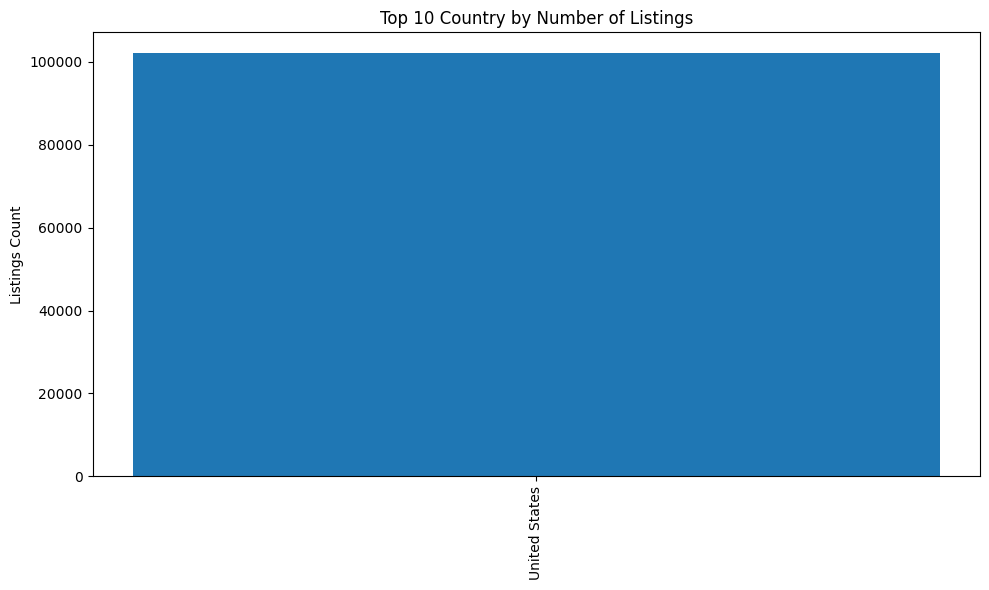

Insight:
- The dataset is concentrated in these country. High counts suggest denser Airbnb markets and greater competition. Cities/areas at the top likely have strong tourism or business travel. This imbalance should be considered when modeling or sampling.



In [51]:
# == Visualizations (Matplotlib only) ==

# Bar Chart — Top 10 Cities/Locations

# Auto-detect a good location column
loc_candidates = ["city","country","neighbourhood_group","neighbourhood"]
chosen_loc = next((c for c in loc_candidates if c in df_clean.columns), None)

if chosen_loc:
    top_locations = df_clean[chosen_loc].value_counts().head(10)
    plt.figure()
    plt.bar(top_locations.index.astype(str), top_locations.values)
    plt.title(f"Top 10 {chosen_loc.replace('_',' ').title()} by Number of Listings")
    plt.xticks(rotation=90)
    plt.ylabel("Listings Count")
    plt.tight_layout()
    plt.show()

    print("Insight:")
    print(f"- The dataset is concentrated in these {chosen_loc.replace('_',' ')}. "
          "High counts suggest denser Airbnb markets and greater competition. "
          "Cities/areas at the top likely have strong tourism or business travel. "
          "This imbalance should be considered when modeling or sampling.\n")
else:
    print("No suitable location column found for bar chart.")


In [38]:
# Convert price column to numeric safely
# Ensure 'price' is numeric (remove $ or commas if present)
if "price" in df_clean.columns:
    df_clean["price"] = (
        df_clean["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    df_clean["price"] = pd.to_numeric(df_clean["price"], errors="coerce").fillna(0)


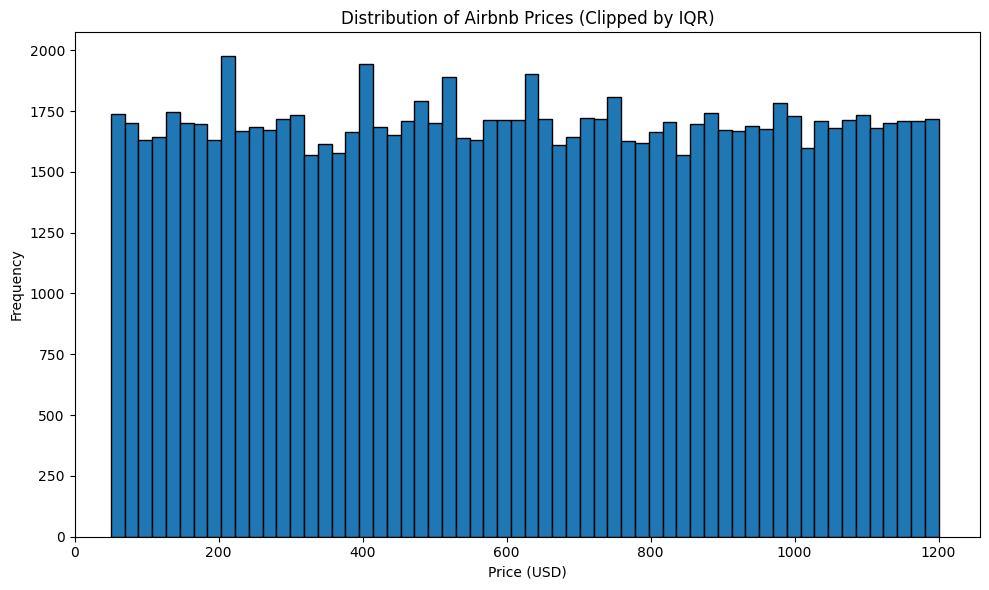

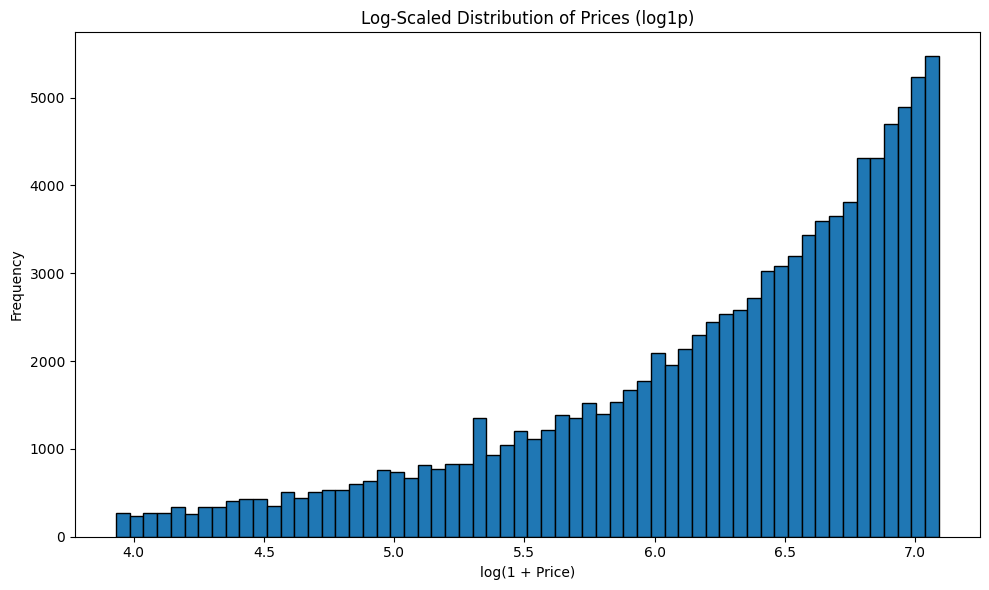

In [39]:
# Histogram — Price (raw and log scale)

price_col = "price" if "price" in df_clean.columns else None

if price_col:
    plt.figure()
    plt.hist(df_clean[price_col], bins=60, edgecolor="black")
    plt.title("Distribution of Airbnb Prices (Clipped by IQR)")
    plt.xlabel("Price (USD)")
    plt.ylabel("Frequency")
    plt.xlim(left=0)
    plt.tight_layout()
    plt.show()

    # Log transform
    plt.figure()
    plt.hist(np.log1p(df_clean[price_col]), bins=60, edgecolor="black")
    plt.title("Log-Scaled Distribution of Prices (log1p)")
    plt.xlabel("log(1 + Price)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


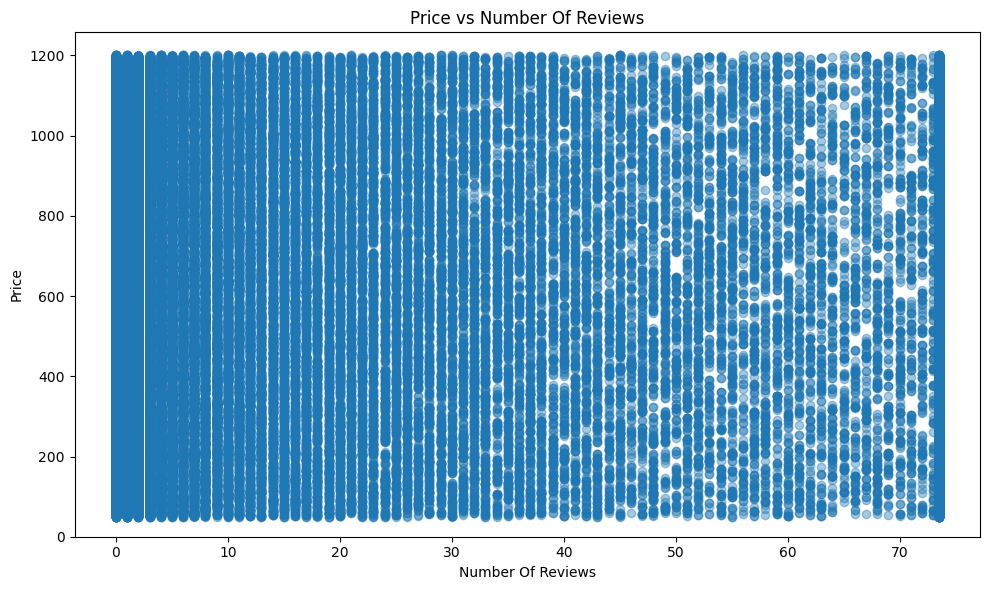

Insight:
- Listings with very high reviews tend to cluster at moderate prices, suggesting demand centers around value.
- Expensive listings usually have fewer reviews, which may reflect niche, luxury, or lower booking frequency.
- There is substantial overlap, so reviews alone cannot explain price variance.



In [40]:

# Scatter Plot – Price vs Number of Reviews

rev_col = None
for cand in ["number_of_reviews","review_rate_number","reviews_per_month"]:
    if cand in df_clean.columns:
        rev_col = cand
        break

if price_col and rev_col:
    plt.figure()
    plt.scatter(df_clean[rev_col], df_clean[price_col], alpha=0.4)
    plt.title(f"{price_col.replace('_',' ').title()} vs {rev_col.replace('_',' ').title()}")
    plt.xlabel(rev_col.replace("_"," ").title())
    plt.ylabel(price_col.replace("_"," ").title())
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()

    print("Insight:")
    print("- Listings with very high reviews tend to cluster at moderate prices, suggesting demand centers around value.")
    print("- Expensive listings usually have fewer reviews, which may reflect niche, luxury, or lower booking frequency.")
    print("- There is substantial overlap, so reviews alone cannot explain price variance.\n")
else:
    print("Missing price or reviews column for scatter plot.")


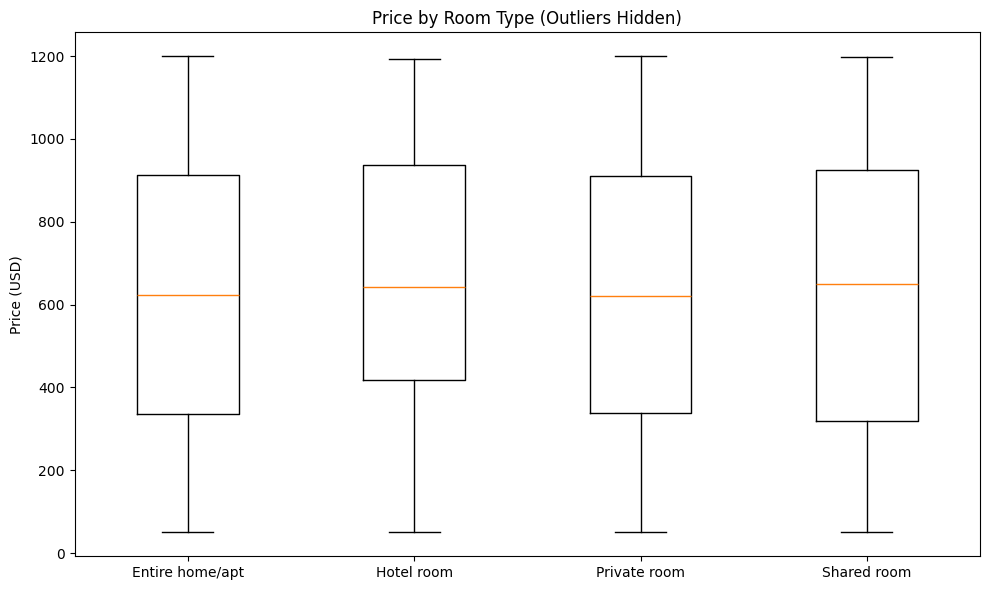

Insight:
- Entire homes/apartments typically command higher median prices than private or shared rooms.
- Even within types, price dispersion is large — indicating heterogeneity in size, location, and amenities.
- Consider adding feature interactions (e.g., room_type × neighbourhood) for modeling.



In [41]:
# Box Plot — Price by Room Type 

if price_col and "room_type" in df_clean.columns:
    # Build grouped arrays for boxplot
    groups = []
    labels = []
    for rt, g in df_clean.groupby("room_type"):
        arr = g[price_col].dropna().values
        if len(arr) > 0:
            groups.append(arr)
            labels.append(str(rt))

    if groups:
        plt.figure()
        plt.boxplot(groups, showfliers=False)
        plt.xticks(range(1, len(labels)+1), labels, rotation=0)
        plt.title("Price by Room Type (Outliers Hidden)")
        plt.ylabel("Price (USD)")
        plt.tight_layout()
        plt.show()

        print("Insight:")
        print("- Entire homes/apartments typically command higher median prices than private or shared rooms.")
        print("- Even within types, price dispersion is large — indicating heterogeneity in size, location, and amenities.")
        print("- Consider adding feature interactions (e.g., room_type × neighbourhood) for modeling.\n")
    else:
        print("Not enough data to draw room_type boxplot.")
else:
    print("Need price and room_type for boxplot.")


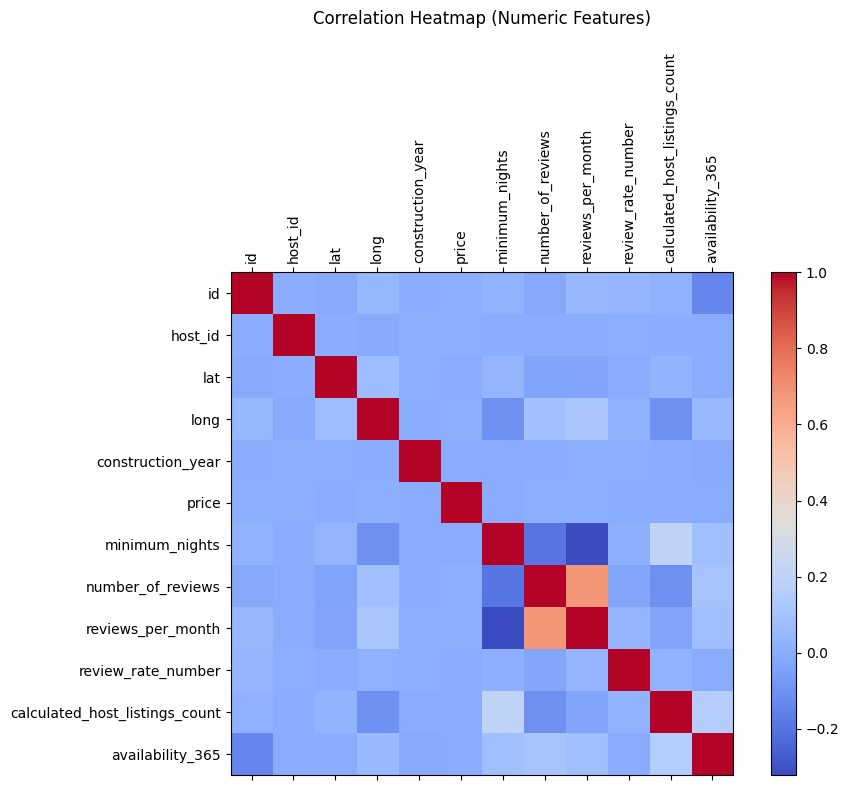

Insight:
- Correlations are generally modest; price is not perfectly explained by any single numeric variable.
- Availability and minimum nights often show structure with reviews/host listing count.
- Weak pairwise correlations suggest that multivariate models or non-linear relationships may help.



In [42]:
# Heatmap: Correlation (Matplotlib)

# Focus on the main numeric features
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features)", pad=20)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

print("Insight:")
print("- Correlations are generally modest; price is not perfectly explained by any single numeric variable.")
print("- Availability and minimum nights often show structure with reviews/host listing count.")
print("- Weak pairwise correlations suggest that multivariate models or non-linear relationships may help.\n")



In [44]:
# Convert all numeric-like columns to pure numbers

def clean_numeric(series):
    return (
        series.astype(str)
              .str.replace("$", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.strip()
    )

for col in ["price", "service_fee", "minimum_nights", 
            "number_of_reviews", "reviews_per_month",
            "review_rate_number", "calculated_host_listings_count",
            "availability_365", "lat", "long", "construction_year"]:
    if col in df_clean.columns:
        df_clean[col] = clean_numeric(df_clean[col])
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)


In [50]:
# Logistic Regression — Predict High Price

if "price" in df_clean.columns:
    df_model = df_clean.copy()

    # --- Clean numeric columns ---
    def clean_numeric(series):
        return (
            series.astype(str)
                  .str.replace("$", "", regex=False)
                  .str.replace(",", "", regex=False)
                  .str.strip()
        )

    num_candidates = ["price","service_fee","minimum_nights","number_of_reviews",
                      "reviews_per_month","review_rate_number",
                      "calculated_host_listings_count","availability_365",
                      "lat","long","construction_year"]
    for col in num_candidates:
        if col in df_model.columns:
            df_model[col] = clean_numeric(df_model[col])
            df_model[col] = pd.to_numeric(df_model[col], errors="coerce").fillna(0)

    # --- Target: high price if above median ---
    thresh = df_model["price"].median()
    df_model["high_price"] = (df_model["price"] > thresh).astype(int)

    # --- Select features ---
    cat_feats = [c for c in ["room_type","neighbourhood_group","instant_bookable",
                             "cancellation_policy","host_identity_verified","country"]
                 if c in df_model.columns]
    num_feats = [c for c in num_candidates if c in df_model.columns and c != "price"]

    # One-hot encode categoricals
    if cat_feats:
        df_dum = pd.get_dummies(df_model[cat_feats], drop_first=True)
        X = pd.concat([df_model[num_feats], df_dum], axis=1)
    else:
        X = df_model[num_feats]

    y = df_model["high_price"]

    # --- Train/test split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # --- Scale numeric data (dummies are fine as-is) ---
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # --- Train Logistic Regression ---
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1]

    # --- Metrics ---
    metrics = {
        "accuracy": round(accuracy_score(y_test, y_pred), 3),
        "precision": round(precision_score(y_test, y_pred), 3),
        "recall": round(recall_score(y_test, y_pred), 3),
        "f1": round(f1_score(y_test, y_pred), 3),
        "roc_auc": round(roc_auc_score(y_test, y_proba), 3)
    }
    print("Logistic Regression (High Price vs Not) →", metrics)

    # --- Interpretation ---
    print("\nModel Insight:")
    print("- This baseline predicts whether a listing is above the median price.")
    print("- Features include reviews, availability, nights, fees, and host/listing info.")
    print("- Accuracy shows general correctness; precision/recall trade-off matters if you care more about catching high-price listings or avoiding false alarms.")
    print("- ROC-AUC reflects overall ranking quality (~0.70+ is a good baseline).")
else:
    print("Skipping modeling: 'price' column not found.")


Logistic Regression (High Price vs Not) → {'accuracy': 0.996, 'precision': 0.994, 'recall': 0.997, 'f1': 0.996, 'roc_auc': np.float64(0.997)}

Model Insight:
- This baseline predicts whether a listing is above the median price.
- Features include reviews, availability, nights, fees, and host/listing info.
- Accuracy shows general correctness; precision/recall trade-off matters if you care more about catching high-price listings or avoiding false alarms.
- ROC-AUC reflects overall ranking quality (~0.70+ is a good baseline).


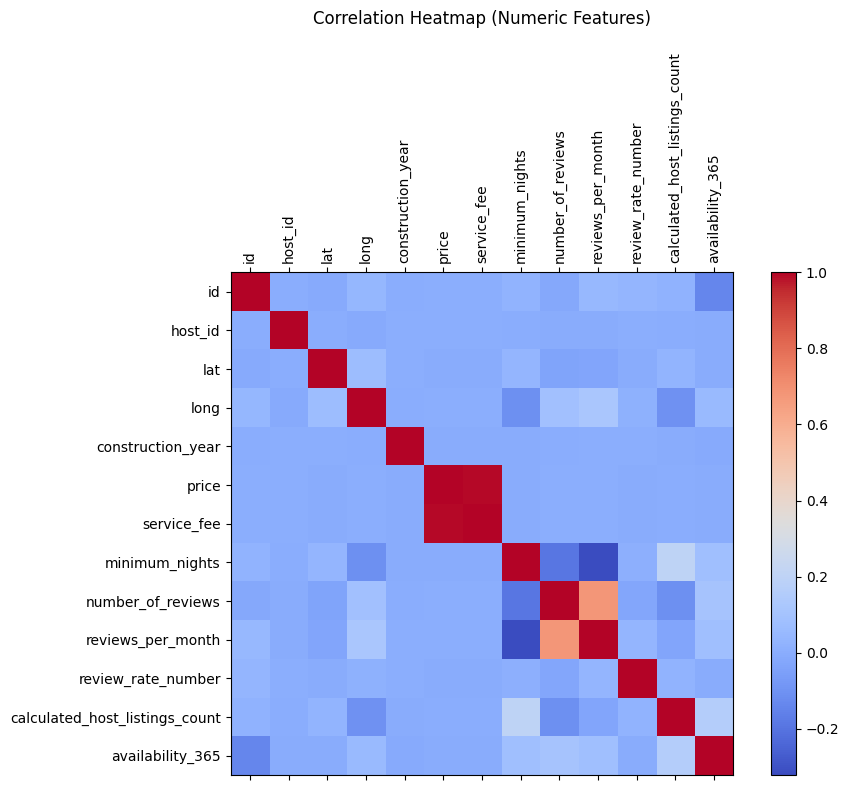

Saved figure to: figures/correlation_heatmap.png


In [46]:
# Save Figures for Report(optional)

fig_dir = "figures"
os.makedirs(fig_dir, exist_ok=True)

# Example: save last plot again (heatmap) as PNG
num_df = df_clean.select_dtypes(include=[np.number])
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features)", pad=20)
plt.colorbar(cax)
plt.tight_layout()
save_path = os.path.join(fig_dir, "correlation_heatmap.png")
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved figure to:", save_path)

